2026-03-17 22:38:34.691682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773787114.888438      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773787114.949708      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773787115.440979      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773787115.441017      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773787115.441020      55 computation_placer.cc:177] computation placer alr

325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


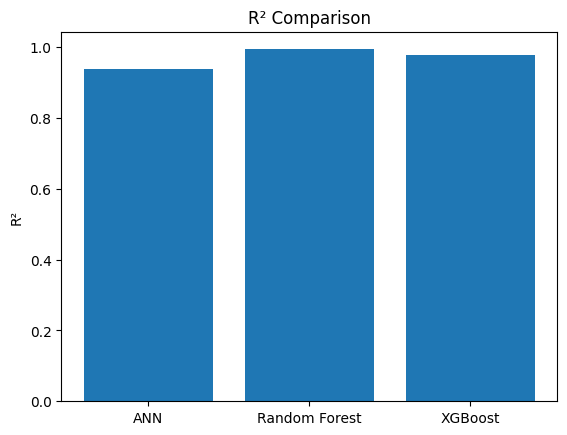

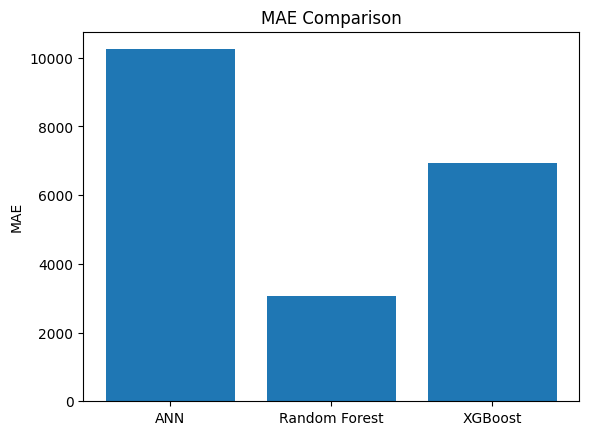

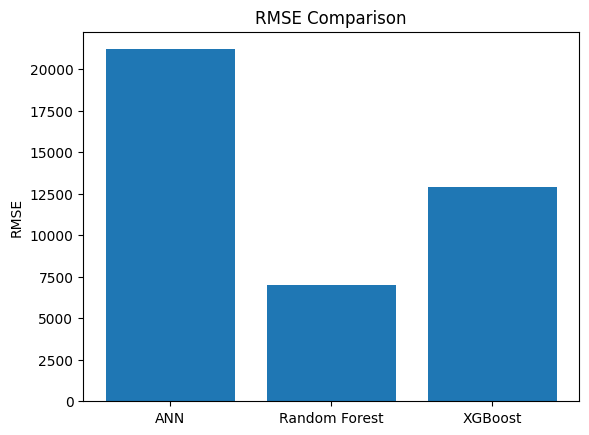

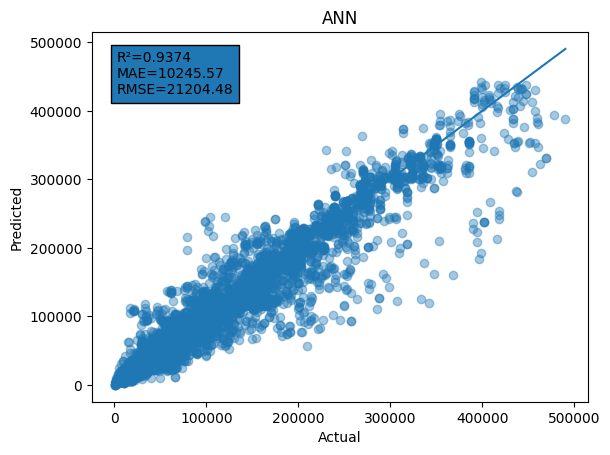

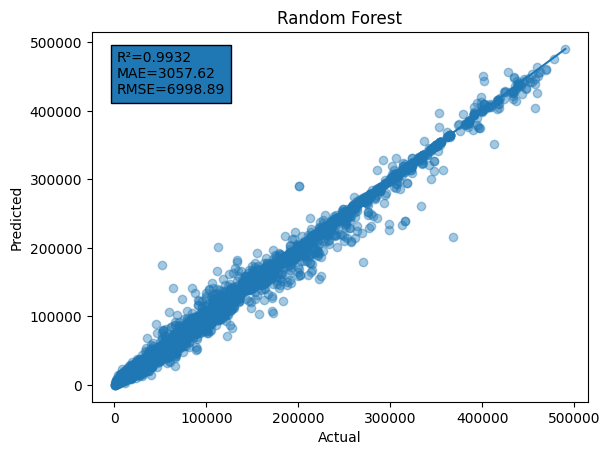

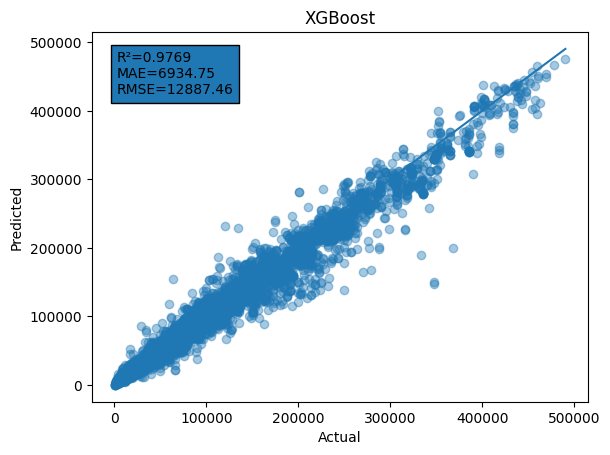


========== FINAL RESULTS ==========

ANN
R²   = 0.9374
MAE  = 10245.57
RMSE = 21204.48
----------------------------------
FINISHED ✅
Random Forest
R²   = 0.9932
MAE  = 3057.62
RMSE = 6998.89
----------------------------------
FINISHED ✅
XGBoost
R²   = 0.9769
MAE  = 6934.75
RMSE = 12887.46
----------------------------------
FINISHED ✅


In [2]:
# ============================================
# FINAL OPTIMIZED VERSION + DATASET 2
# ANN (with PCA) vs RF (GridSearch) vs XGBoost
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Models
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

# ============================================
# 1. LOAD DATA
# ============================================

df = pd.read_csv("/kaggle/input/datasets/sarahgourari/crop-data/yield_df.csv")

# ============================================
# 2. DATA CLEANING
# ============================================

df.drop(columns=["Unnamed: 0"], inplace=True)
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

# ============================================
# 2.1 GENERATE DATASET 2 (Synthetic Data)
# ============================================

# Bootstrapping
df_synthetic = df.sample(frac=1, replace=True, random_state=42)

# Optional (stronger): Add small noise
numeric_features = [
    "Year",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]

df_synthetic[numeric_features] += np.random.normal(0, 0.01, df_synthetic[numeric_features].shape)

# Combine datasets
df_combined = pd.concat([df, df_synthetic], ignore_index=True)

# ============================================
# 3. FEATURES & TARGET
# ============================================

X = df_combined.drop(columns=["hg/ha_yield"])
y = np.log1p(df_combined["hg/ha_yield"])

categorical_features = ["Area", "Item"]

# ============================================
# 4. PREPROCESSING
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ============================================
# 5. SPLIT DATA
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)

y_test_real = np.expm1(y_test)

# ============================================
# 6. PCA (FOR ANN ONLY)
# ============================================

pca = PCA(n_components=30)
X_train_ann = pca.fit_transform(X_train)
X_test_ann  = pca.transform(X_test)

# ============================================
# 7. ANN MODEL
# ============================================

ann = Sequential([
    Input(shape=(X_train_ann.shape[1],)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dense(1)
])

ann.compile(optimizer="adam", loss="mse")

ann.fit(
    X_train_ann, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=0
)

y_pred_ann = np.expm1(ann.predict(X_test_ann).flatten())

# ============================================
# 8. RANDOM FOREST (GRID SEARCH + CV)
# ============================================

rf = RandomForestRegressor(random_state=42)

param_rf = {
    "n_estimators": [200, 300],
    "max_depth": [10, 20]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = np.expm1(best_rf.predict(X_test))

# ============================================
# 9. XGBOOST
# ============================================

xgb = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = np.expm1(xgb.predict(X_test))

# ============================================
# 10. METRICS
# ============================================

models = ["ANN", "Random Forest", "XGBoost"]
preds  = [y_pred_ann, y_pred_rf, y_pred_xgb]

R2, MAE, RMSE = [], [], []

for p in preds:
    R2.append(r2_score(y_test_real, p))
    MAE.append(mean_absolute_error(y_test_real, p))
    RMSE.append(np.sqrt(mean_squared_error(y_test_real, p)))

# ============================================
# 11. PERFORMANCE PLOTS
# ============================================

def plot_bar(values, title, ylabel, filename):
    plt.figure()
    plt.bar(models, values)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_bar(R2, "R² Comparison", "R²", "R2.png")
plot_bar(MAE, "MAE Comparison", "MAE", "MAE.png")
plot_bar(RMSE, "RMSE Comparison", "RMSE", "RMSE.png")

# ============================================
# 12. ACTUAL VS PREDICTED
# ============================================

def plot_actual_vs_pred(y_true, y_pred, model_name):

    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.figure()
    plt.scatter(y_true, y_pred, alpha=0.4)

    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(model_name)

    plt.text(
        0.05, 0.95,
        f"R²={r2:.4f}\nMAE={mae:.2f}\nRMSE={rmse:.2f}",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict()
    )

    plt.savefig(model_name + ".png", dpi=300, bbox_inches="tight")
    plt.show()

for i in range(len(models)):
    plot_actual_vs_pred(y_test_real, preds[i], models[i])

# ============================================
# 13. FINAL RESULTS
# ============================================

print("\n========== FINAL RESULTS ==========\n")

for i in range(len(models)):
    print(models[i])
    print(f"R²   = {R2[i]:.4f}")
    print(f"MAE  = {MAE[i]:.2f}")
    print(f"RMSE = {RMSE[i]:.2f}")
    print("----------------------------------")
    print("FINISHED ✅")